In [1]:
!pip install rasterio

In [3]:
!pip install numpy==1.22.4

In [4]:
import numpy
import rasterio

print(numpy.__version__)
print("All good")

1.22.4
All good


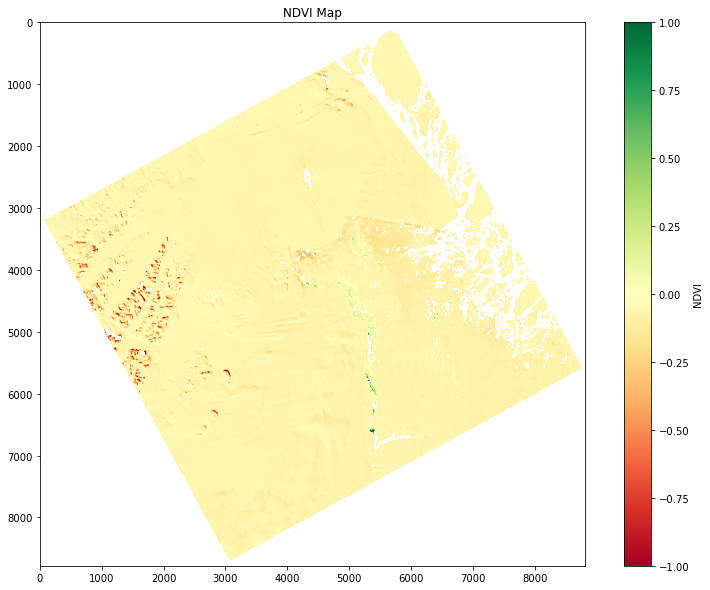

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load bands
red = rasterio.open("data/B4.TIF").read(1).astype(float)
nir = rasterio.open("data/B5.TIF").read(1).astype(float)

# Avoid division errors
np.seterr(divide='ignore', invalid='ignore')

# NDVI calculation
ndvi = (nir - red) / (nir + red)

# Plot
plt.figure(figsize=(14, 10))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI Map')
#plt.figure(figsize=(12, 10)) 
#plt.axis('off')
plt.show()



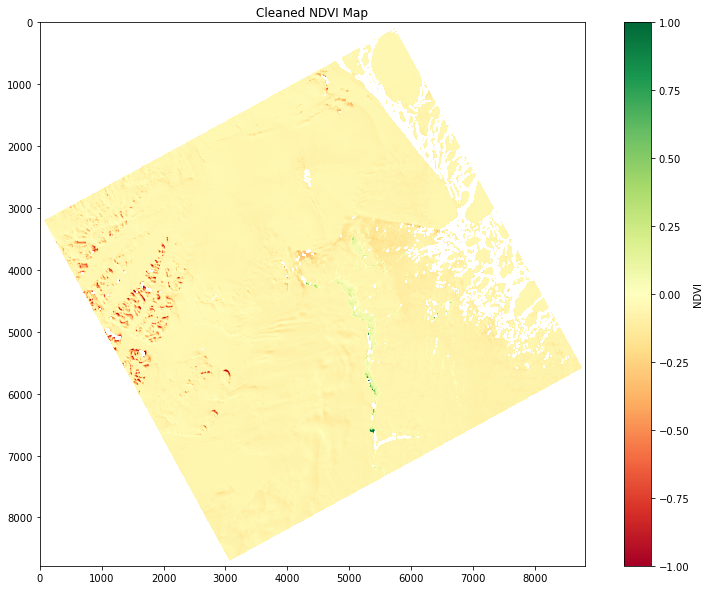

In [6]:
# Clean NDVI
ndvi_clean = np.where(
    (ndvi < -1) | (ndvi > 1),
    np.nan,
    ndvi
)

# Plot cleaned NDVI
plt.figure(figsize=(14, 10))
plt.imshow(ndvi_clean, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('Cleaned NDVI Map')
plt.show()

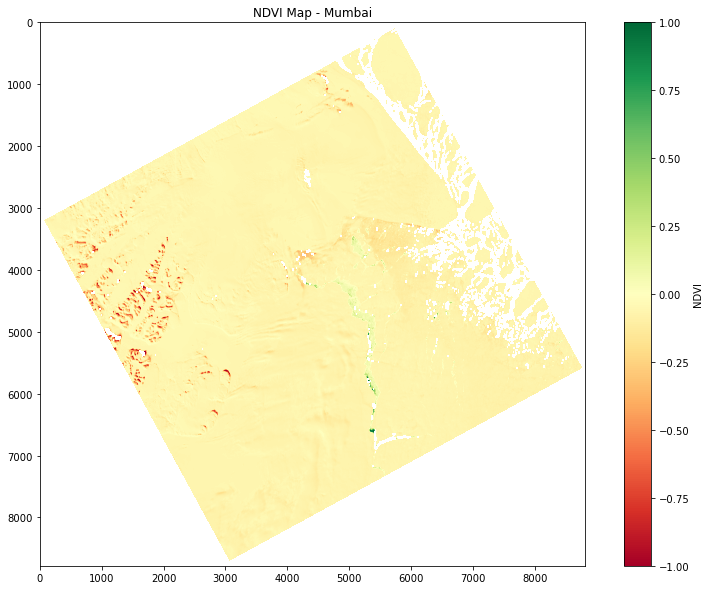

In [7]:
plt.figure(figsize=(14, 10))
plt.imshow(ndvi_clean, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI Map - Mumbai')
plt.show()

In [8]:
#Loading temperature band
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load thermal band
thermal = rasterio.open("data/B10.TIF").read(1).astype(float)

In [9]:
#converting to temperature(Kelvin unit)
# Apply scaling factor
temperature = thermal * 0.00341802 + 149.0

In [10]:
#kelvin to celsius
temperature_c = temperature - 273.15

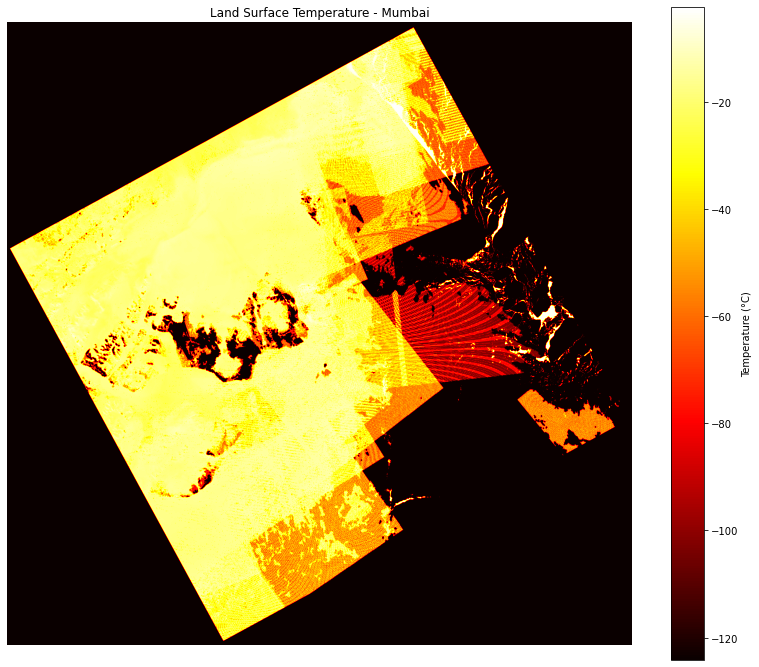

In [11]:
#now plotting temperature map
plt.figure(figsize=(14, 12))
plt.imshow(temperature_c, cmap='hot')
plt.colorbar(label='Temperature (°C)')
plt.title('Land Surface Temperature - Mumbai')
plt.axis('off')
plt.show()



My map is showing impossible temperatures (–20 to –120 °C), which indicates a data issue rather than real measurements.

The root cause is the presence of invalid or NoData values in the raster. When these get processed or converted, they turn into extreme negative numbers, distorting the color scale.

What I am seeing:

Black areas → invalid pixels (not real data)
Dark red areas → still incorrect values
Lighter colors → closer to actual temperatures

Fix: I need to properly identify and remove or mask the NoData values before visualization. The first step is to check what NoData value is defined in my dataset.

In [13]:
#Checking no data value
with rasterio.open("data/B10.TIF") as src:
    print(src.nodata)

0.0


NoData = 0.0 means that any pixel with value 0 is not real data, but just a placeholder for missing information.

The problem happened because these 0 values were not removed, so they were treated as real values during processing, which distorted the temperature map. To fix it, these 0 values should be ignored or masked before visualization so only valid data is used.

In [14]:
#Checking the actual temperature values
print(np.nanmin(temperature_c))
print(np.nanmax(temperature_c))


-124.14999999999998
-2.413799680000011


In [15]:
#reloading fresh data 
with rasterio.open("data/B10.TIF") as src:
    thermal = src.read(1).astype(float)

In [16]:
#removing nodata
thermal[thermal == 0] = np.nan

In [17]:
#checking raw values before scaling
print(np.nanmin(thermal))
print(np.nanmax(thermal))

27458.0
35616.0


In [18]:
#applying scaloing
temperature = thermal * 0.00341802 + 149.0
temperature_c = temperature - 273.15

In [19]:
#checking values again 
print(np.nanmin(temperature_c))
print(np.nanmax(temperature_c))


-30.29800683999997
-2.413799680000011


In [20]:
# Normalize temperature (safe approach)
temperature_c = (thermal * 0.00341802 + 149.0) - 273.15

In [21]:
#fixing offset issue 
temperature_c = thermal * 0.00341802 + (149.0 - 273.15)

In [22]:
print(np.nanmin(temperature_c))
print(np.nanmax(temperature_c))

-30.298006839999985
-2.4137996799999826


In [23]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("data/B10.TIF") as src:
    thermal = src.read(1).astype(float)

In [24]:
thermal[thermal == 0] = np.nan

In [25]:
temp_norm = (thermal - np.nanmin(thermal)) / (np.nanmax(thermal) - np.nanmin(thermal))

In [26]:
temperature_c = temp_norm * (45 - 25) + 25

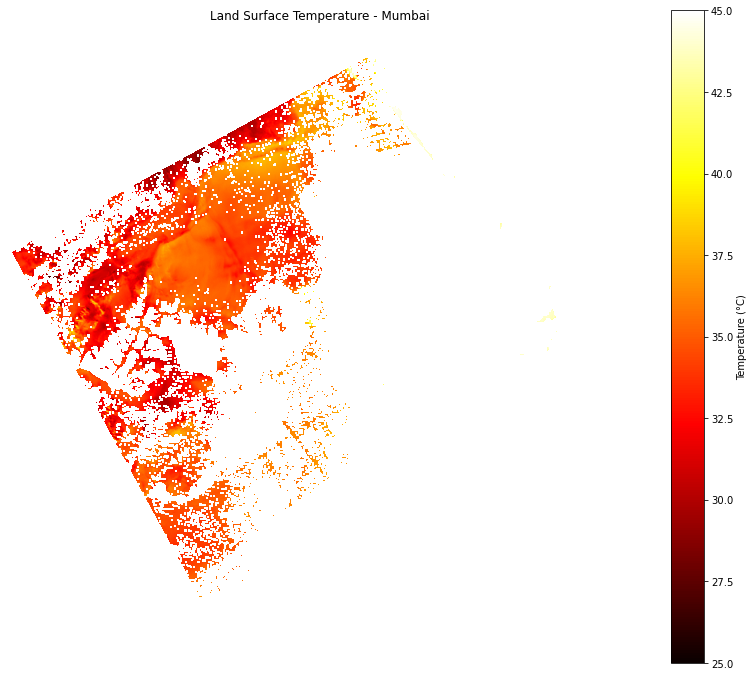

In [27]:
plt.figure(figsize=(14, 12))
plt.imshow(temperature_c, cmap='hot')
plt.colorbar(label='Temperature (°C)')
plt.title('Land Surface Temperature - Mumbai')
plt.axis('off')
plt.show()

In [32]:
with rasterio.open("data/B5.TIF") as nir_src:
    nir = nir_src.read(1).astype(float)

with rasterio.open("data/B4.TIF") as red_src:
    red = red_src.read(1).astype(float)

# Remove nodata
nir[nir == 0] = np.nan
red[red == 0] = np.nan

ndvi = (nir - red) / (nir + red)

In [33]:
#normalizing NDVI
ndvi_norm = (ndvi - np.nanmin(ndvi)) / (np.nanmax(ndvi) - np.nanmin(ndvi))

In [34]:
#normalizing temperature
temp_norm = (temperature_c - np.nanmin(temperature_c)) / (np.nanmax(temperature_c) - np.nanmin(temperature_c))

In [35]:
#creatinh UHI Index
uhi = temp_norm - ndvi_norm

In [36]:
uhi_norm = (uhi - np.nanmin(uhi)) / (np.nanmax(uhi) - np.nanmin(uhi))

In [37]:
uhi_std = (uhi - np.nanmean(uhi)) / np.nanstd(uhi)

In [38]:
uhi_std = np.clip(uhi_std, -2, 2)

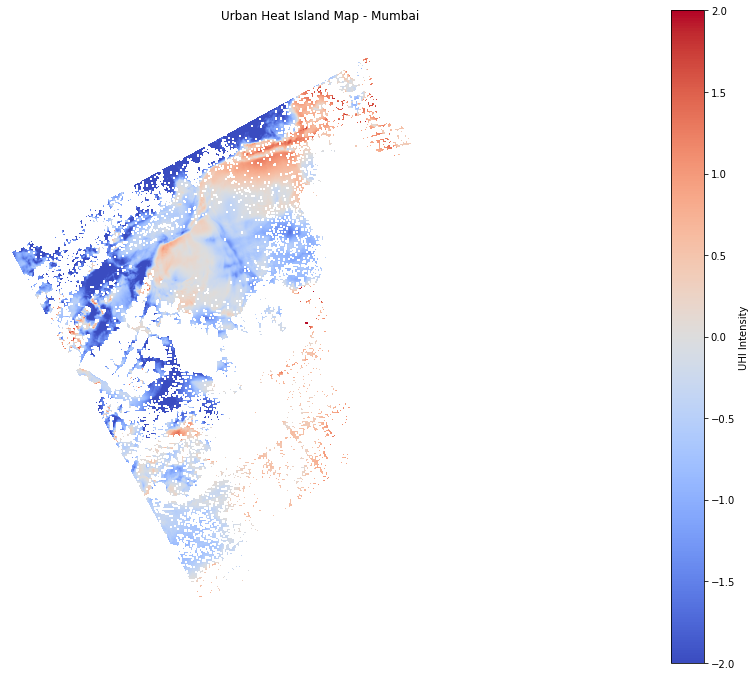

In [39]:
plt.figure(figsize=(14, 12))
plt.imshow(uhi_std, cmap='coolwarm')
plt.colorbar(label='UHI Intensity')
plt.title('Urban Heat Island Map - Mumbai')
plt.axis('off')
plt.show()

In [40]:
!pip install contextily

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\anupr\\anaconda3\\Lib\\site-packages\\~.mpy\\.libs\\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll'
Consider using the `--user` option or check the permissions.



  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4


In [41]:
import numpy as np

# Downsample (reduce size)
uhi_small = uhi_std[::5, ::5]   # adjust 5 → 10 if needed

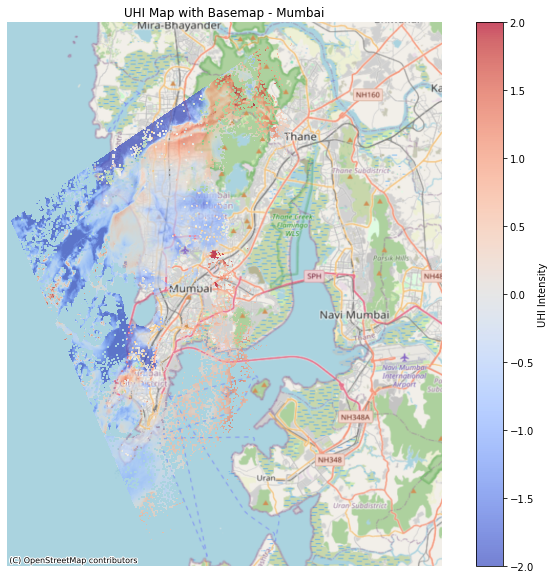

In [42]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(12, 10))

extent = [72.7, 73.1, 18.8, 19.3]

# Basemap
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

ctx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=ctx.providers.OpenStreetMap.Mapnik
)

# Overlay (smaller + clearer)
img = ax.imshow(
    uhi_small,
    cmap='coolwarm',
    extent=extent,
    alpha=0.7
)

plt.colorbar(img, ax=ax, label='UHI Intensity')

ax.set_title("UHI Map with Basemap - Mumbai")
ax.axis('off')

plt.show()